In [ ]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d paufortiana/open-food-facts-with-nutriscore-and-generic-names
!unzip open-food-facts-with-nutriscore-and-generic-names.zip

In [25]:
import pandas as pd

# load dataset into df
df = pd.read_csv("open-food-facts-initial-filter.csv", sep="\t", low_memory=False)

print(df["nutriscore_grade"].value_counts())

nutriscore_grade
d    29656
c    23233
e    19949
a    18906
b    16327
Name: count, dtype: int64


In [26]:
# start preprocessing data
df_clean = df.dropna(subset=["ingredients_text", "nutriscore_grade"]).copy()

df_clean["ingredients_text"] = df_clean["ingredients_text"].str.lower()
df_clean["ingredients_text"] = df_clean["ingredients_text"].str.replace(r'[^a-z\s,]', '', regex=True)

print(len(df_clean))

103196


In [27]:
import numpy as np
from tensorflow.keras.layers import TextVectorization

MAX_WORDS = 10000
MAX_LEN = 150

vectorizer = TextVectorization(
    max_tokens=MAX_WORDS,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

vectorizer.adapt(df_clean["ingredients_text"].values)

X = vectorizer(df_clean["ingredients_text"].values).numpy()

In [28]:
from tensorflow.keras.utils import to_categorical

mapping = {"a": 0, "b": 1, "c": 2, "d": 3, "e": 4}
y_ints = df_clean["nutriscore_grade"].map(mapping).values

# one-hot encoding
y = to_categorical(y_ints, num_classes=5)

In [ ]:
# let's examine the "ingredients_text" column
sample_data = df_clean["ingredients_text"].sample(15)

for text in sample_data:
    print(text)

# we have seen that the input exists in different languages, however, let's continue with tokenizing

In [30]:
# count the number of unique words
all_text = " ".join(df_clean["ingredients_text"].astype(str))
unique_words = set(all_text.split())

print(f"Count of unique words: {len(unique_words)}")

Count of unique words: 63703


In [31]:
# split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=58)
print(X_train.shape)

(92876, 150)


In [32]:
# observe the length of each input
df_clean["length"] = df_clean["ingredients_text"].apply(lambda x: len(str(x).split()))

print(f"Average Length: {df_clean["length"].mean():.1f}")
print(f"95th Percentile: {df_clean["length"].quantile(0.95):.1f}")
print(f"Maximum Length: {df_clean["length"].max()}")

Average Length: 31.9
95th Percentile: 87.0
Maximum Length: 685


In [33]:
# let's construct the model
from tensorflow.keras import layers, models, regularizers

VOCAB_SIZE = 10000
MAX_LEN = 150
EMBED_DIM = 32

input_layer = layers.Input(shape=(MAX_LEN, ))

x = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM)(input_layer)
x = layers.Conv1D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation="relu")(x)
output_layer = layers.Dense(5, activation="softmax")(x)

model = models.Model(inputs=input_layer, outputs=output_layer)

In [34]:
# compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"])

In [35]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50
2322/2322 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.3938 - loss: 1.3630 - val_accuracy: 0.5445 - val_loss: 1.0882
Epoch 2/50
2322/2322 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5611 - loss: 1.0435 - val_accuracy: 0.5682 - val_loss: 1.0203
Epoch 3/50
2322/2322 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6060 - loss: 0.9495 - val_accuracy: 0.5824 - val_loss: 0.9977
Epoch 4/50
2322/2322 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6308 - loss: 0.8965 - val_accuracy: 0.6003 - val_loss: 0.9798
Epoch 5/50
2322/2322 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6480 - loss: 0.8588 - val_accuracy: 0.6047 - val_loss: 0.9811
Epoch 6/50
2322/2322 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6766 - loss: 0.8078 - val_accuracy: 0.6030 - val_loss: 0.9968
Epoch 7/50
2322/2322 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6897 - loss: 0.7732 - val_accuracy: 0.6098 - val_loss: 0.9872
Epoch 8/50
2322/2322 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.7118 - loss: 0.7288 -

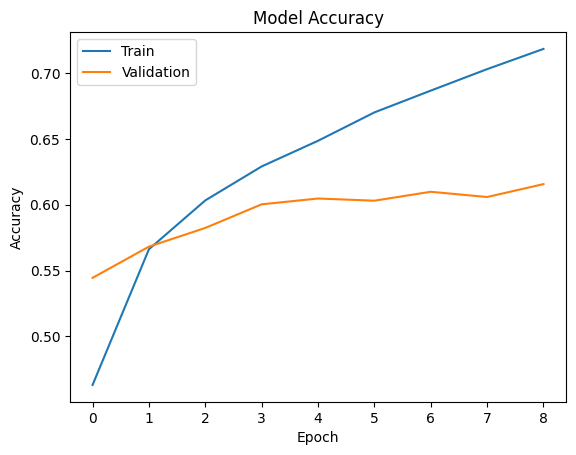

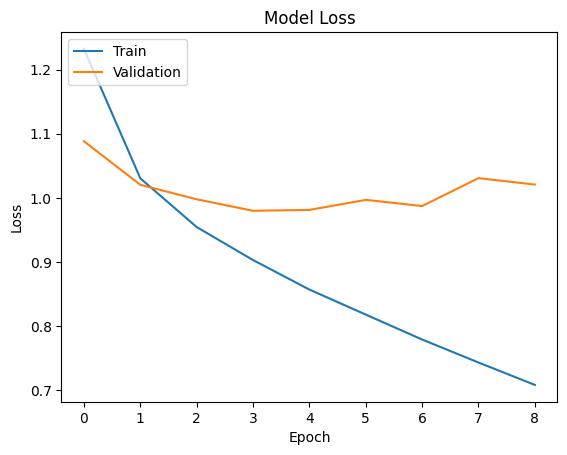

In [36]:
import matplotlib.pyplot as plt

# plot accuracy values
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()

# plot loss values
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"], loc="upper left")
plt.show()